# Computing Time-Dependent Coefficients $c_{nlm}(t)$ for ULDM Wavefunctions

This notebook projects ultralight dark matter (ULDM) wavefunctions onto a radial eigenbasis and spherical harmonics to compute the time-dependent expansion coefficients $c_{nlm}(t)$.

## Overview

The workflow consists of three main phases:

1. **Data Loading & Grid Setup** (Steps 1–6): Load pre-computed eigenfunctions and spherical harmonic coefficients, configure the radial integration grid.

2. **Coefficient Computation** (Steps 7–8): Perform the radial integrals to obtain $c_{nlm}(t)$, with optional time interpolation for denser sampling.

3. **Visualization & Analysis** (Steps 9–14): Generate diagnostic plots, spectral analysis, and publication-ready figures.

## Prerequisites

- **Eigenfunctions file** (`.h5`): Pre-computed radial eigenfunctions $f_{nl}(r)$ from Schrödinger–Poisson solver.
- **Spherical harmonic file** (`.h5`): Time-dependent spherical harmonic coefficients $a_{lm}(r,t)$ from PyUL simulations.
- **Python packages**: `numpy`, `scipy`, `matplotlib`, `h5py`, plus the local `Eig_ULDM_packages` module.

## Key Functions Used

| Function | Module | Purpose |
|----------|--------|---------|
| `load_eigenfunctions()` | `c_nlm_integrator` | Load radial eigenfunctions from HDF5 |
| `load_a_lm()` | `c_nlm_integrator` | Load spherical harmonic coefficients |
| `compute_cnlm()` | `c_nlm_integrator` | Compute $c_{nlm}(t)$ via radial integration |
| `save_cnlm_to_h5()` / `load_cnlm_from_h5()` | `c_nlm_integrator` | HDF5 I/O for coefficient data |
| `resample_cnlm_time()` | `c_nlm_integrator` | Time interpolation with Savitzky–Golay smoothing |
| `analyze_cnlm_spectrum()` | `cnlm_spectral_analysis` | FFT-based spectral analysis |
| `plot_4panel_eda()` | `cnlm_spectral_analysis` | 4-panel exploratory diagnostic figure |
| `export_prd_figure()` | `cnlm_spectral_analysis` | Publication-ready EPS export |

## Step 1: Import Libraries and Initialize Environment

Import required Python packages and the custom `Eig_ULDM_packages` modules. This cell also:
- Sets the axion mass via environment variable `PYUL_AXION_MASS_EV`
- Loads unit conversion functions from `Eig_ULDM_packages.units`
- Prints version information for reproducibility

**Note**: The `importlib.reload()` call ensures that any local edits to the module are picked up during development.

In [ ]:
# Imports and version information
import numpy as np
import matplotlib.pyplot as plt
import scipy
import importlib
import Eig_ULDM_packages.c_nlm_integrator as _cni
import os
os.environ["PYUL_AXION_MASS_EV"] = "1e-21"
from Eig_ULDM_packages.units import *
# Always reload to pick up local edits during development
_cni = importlib.reload(_cni)
from Eig_ULDM_packages.c_nlm_integrator import *

print(f'numpy version: {np.__version__}')
print(f'scipy version: {scipy.__version__}')
try:
    import h5py
    print(f'h5py version: {h5py.__version__}')
except ImportError:
    print('h5py is not installed; reading/writing HDF5 files will fail.')

numpy version: 1.26.4
scipy version: 1.13.1
h5py version: 3.12.1


## Step 2: Define Utility Function

A helper function `print_once()` that prevents duplicate print statements when cells are re-executed. This is useful during iterative development to keep the output clean.

In [2]:
# Utility: print once per key to avoid accidental duplicated outputs
_print_once_keys = set()

def print_once(key: str, *args, **kwargs):
    if key in _print_once_keys:
        return
    _print_once_keys.add(key)
    print(*args, **kwargs)

## Step 3: Configure File Paths and Parameters

Set up the working directory and specify input/output file paths:

| Variable | Description |
|----------|-------------|
| `work_dir` | Working directory containing all data files |
| `eigs_file` | HDF5 file with pre-computed radial eigenfunctions $f_{nl}(r)$ |
| `alm_file` | HDF5 file with spherical harmonic coefficients $a_{lm}(r,t)$ |
| `c_out_file` | Output file for computed $c_{nlm}(t)$ coefficients |

**Key parameters**:
- `final_time`: Maximum simulation time to load (in Myr)
- `grid_choice`: Radial grid for integration (`'eigen'`, `'alm'`, or `'manual'`)
- `num_workers`: Number of CPU cores for parallel computation

**⚠️ Important**: Modify `work_dir` and file names to match your data location before running.

In [ ]:
# ============================================================================
# USER CONFIGURATION — Modify these paths and parameters for your data
# ============================================================================
work_dir = "/path/to/your/simulation/Outputs"  # <-- CHANGE THIS to your data directory
# Example: work_dir = "/data/user/Stone_Skipping/128_0.02_3000_500/Outputs"

if work_dir:
    os.chdir(work_dir)

# Input files (generated by f_nl_python.ipynb and Main.ipynb)
eigs_file = 'eigenfunctions.h5'      # <-- Radial eigenfunctions from f_nl_python.ipynb
alm_file  = 'PyUL_psi_alm.h5'        # <-- Spherical harmonics from Main.ipynb

# Output file for c_nlm(t) coefficients
c_out_file = 'c_nlm.h5'

# Physical parameter: final simulation time (in Myr)
final_time = 3000

# Choose integration grid resolution: 'eigen', 'alm', or 'manual'
grid_choice = 'eigen'  # 'eigen' uses the eigenfunction grid (recommended)

# Placeholder for manual grid (set after loading eigenfunctions if needed)
r_manual = None

# Number of CPU cores for parallel computation
num_workers = 18
# ============================================================================

## Step 4: Load Radial Eigenfunctions

Load the pre-computed radial eigenfunctions $f_{nl}(r)$ from the HDF5 file. These eigenfunctions are solutions to the Schrödinger–Poisson system and form the basis for expanding the ULDM wavefunction.

**Outputs**:
- `r_f`: Radial grid points for eigenfunctions
- `f_dict`: Dictionary mapping `(n, l)` → eigenfunction array $f_{nl}(r)$
- `r_max_eig`: Maximum radius of the eigenfunction grid

In [4]:
# Load eigenfunctions and display grid information
print('Loading eigenfunctions from', eigs_file)
r_f, f_dict = load_eigenfunctions(eigs_file)
print(f'Eigenfunction grid has {len(r_f)} points from {r_f[0]} to {r_f[-1]}')
dr_f = r_f[1] - r_f[0]
print(f'Eigenfunction radial spacing: {dr_f}')
r_max_eig = float(r_f[-1])

Loading eigenfunctions from eigs_mass_170_Eig_25_lmax_10_nig_5120_py2.h5
Eigenfunction grid has 5120 points from 0.0 to 0.20604798941694438
Eigenfunction radial spacing: 4.0251609575492166e-05


## Step 5: Load Spherical Harmonic Coefficients

Construct a radial grid for the spherical harmonic data and load the coefficients $a_{lm}(r,t)$ from the PyUL simulation output.

The radial grid is:
1. Created in physical units (kpc)
2. Converted to code units
3. Rescaled to match the eigenfunction domain

**Outputs**:
- `r_al_loaded`: Radial grid for $a_{lm}$
- `t_al_loaded`: Time array from simulation
- `a_lm_map`: Dictionary mapping `(l, m)` → 2D array of shape `(n_r, n_t)`

**Note**: The grid rescaling ensures that the spherical harmonic data spans the same radial domain as the eigenfunctions, which is required for accurate numerical integration.

In [5]:
# Construct the spherical harmonic radial grid to match eigenfunction domain
# Define a radial grid for the spherical harmonic data.
# We'll rescale this grid to the eigenfunction maximum radius later.
n_r = 257
r_max     = 2.5*2/2  # ending radius in kpc (box_length / 2, etc.)
r_max_code_units = convert_between(r_max, 'kpc', '', 'l')
r_values = np.linspace(0.0, r_max_code_units, n_r, endpoint=True)
r_values[0] = convert_between(1e-5, 'kpc', '', 'l')  # avoid zero

r_al_grid = (r_values / r_values[-1]) * r_max_eig
print(f'Spherical harmonic grid has {len(r_al_grid)} points from {r_al_grid[0]} to {r_al_grid[-1]}')
dr_al = r_al_grid[1] - r_al_grid[0]
print(f'Spherical harmonic radial spacing: {dr_al}')

# Load spherical harmonic coefficients
print('Loading a_{lm}(r,t) from', alm_file)
alm_data = load_a_lm(alm_file, r_al=r_al_grid, final_time=final_time)
r_al_loaded = alm_data['r']
t_al_loaded = alm_data['t']
a_lm_map = alm_data['a_lm']
print(f'a_lm time grid has {len(t_al_loaded)} samples from t={t_al_loaded[0]} to {t_al_loaded[-1]}')

Spherical harmonic grid has 257 points from 8.241919576677776e-07 to 0.20604798941694438
Spherical harmonic radial spacing: 0.0008040507667022712
Loading a_{lm}(r,t) from PyUL_psi_alm_0.02_mass170_256.h5
a_lm time grid has 501 samples from t=0.0 to 3000.0


## Step 6: Configure Manual Integration Grid (Optional)

If `grid_choice = 'manual'` was set in Step 3, this cell creates a custom radial grid for the numerical integration. This allows fine-tuning of the grid resolution independent of the eigenfunction or $a_{lm}$ grids.

For most cases, using `grid_choice = 'eigen'` (default) is recommended, which uses the eigenfunction grid directly.

In [6]:
# If using a manual integration grid, define it now
if grid_choice == 'manual':
    # Choose a smaller number of points for integration (example)
    n_manual = 512
    r_manual = np.linspace(0.0, r_max_eig, n_manual, endpoint=True)
    print(f'Manual integration grid has {len(r_manual)} points from {r_manual[0]} to {r_manual[-1]}')
else:
    r_manual = None

## Step 7: Compute $c_{nlm}(t)$ Coefficients

This is the main computation step. The coefficients are computed via the radial integral:

$$c_{nlm}(t) = \int_0^{r_{\max}} f_{nl}(r) \, a_{lm}(r,t) \, r^2 \, dr$$

**Caching behavior**:
- If the output file already exists, coefficients are loaded from disk (fast)
- Otherwise, the integral is computed in parallel using `num_workers` CPU cores

**Outputs**:
- `t_ret` / `t_file`: Time array
- `c_dict` / `c_file`: Dictionary mapping `(n, l, m)` → complex coefficient array $c_{nlm}(t)$

**⚠️ Note**: The computation can be time-consuming for large grids. Results are automatically saved to HDF5 for future reuse.

In [34]:
# Compute the c_{nlm}(t) coefficients on the chosen integration grid
# Check if output file already exists to skip expensive computation
import os
if os.path.exists(c_out_file):
    print(f"[SKIP] File '{c_out_file}' already exists. Loading from file instead of recomputing.")
    t_loaded, c_loaded, attrs = load_cnlm_from_h5(c_out_file)
    # Also expose as t_ret, c_dict for compatibility with downstream code
    t_ret = t_loaded
    c_dict = c_loaded
    print(f"Loaded {len(c_dict)} sets of c_{{nlm}}(t) on {len(t_ret)} time points from existing file.")
else:
    print('Computing c_{nlm}(t) coefficients with grid_choice:', grid_choice)
    t_ret, c_dict = compute_cnlm(
        r_f=r_f,
        f_dict=f_dict,
        r_al=r_al_loaded,
        t_al=t_al_loaded,
        a_lm=a_lm_map,
        r_interp_kind='cubic',
        time_interp=None,
        t_out=None,
        grid_choice=grid_choice,
        r_manual=r_manual,
        num_workers=num_workers,
        progress=True,
    )
    print_once('cell7_done', f"Computed {len(c_dict)} sets of c_{{nlm}}(t) on {len(t_ret)} time points")

    # Save the computed coefficients
    print('Saving c_{nlm}(t) to', c_out_file)
    save_cnlm_to_h5(c_dict, t_ret, c_out_file)
    
    # Reload to verify and set t_loaded, c_loaded
    print_once('cell8_reloading', 'Reloading c_{nlm}(t) from file')
    t_loaded, c_loaded, attrs = load_cnlm_from_h5(c_out_file)
    print_once('cell8_reloaded', f'Reloaded {len(c_loaded)} coefficient series with time length {len(t_loaded)}')

[SKIP] File 'c_nlm_mass170.h5' already exists. Loading from file instead of recomputing.
Loaded 3025 sets of c_{nlm}(t) on 501 time points from existing file.


## Step 8: Time Interpolation for Denser Sampling

Create a denser time series by interpolating the original $c_{nlm}(t)$ data. This is useful for:
- Improving FFT frequency resolution
- Smoother visualizations
- Reducing aliasing artifacts

**Method**: `nearest-savgol` — nearest-neighbor interpolation followed by Savitzky–Golay smoothing to preserve signal characteristics while increasing temporal resolution.

**Outputs**:
- `t_dense_from_file`: Dense time array (default: 60,001 points)
- `c_dense_from_file`: Interpolated coefficient dictionary

The dense data is cached to `*_dense_from_file.h5` for reuse.

In [35]:
# Load original c_{nlm}(t) from file (saved in cell 9) and build a denser time series
import os

# First load the original (non-dense) file
print_once('cell11_load', f"Loading original c_{{nlm}}(t) from '{c_out_file}' for post-hoc time interpolation")
t_file, c_file, attrs_file = load_cnlm_from_h5(c_out_file)

# Define output path for dense file
c_out_file_dense_from_file = c_out_file.replace('.h5', '_dense_from_file.h5')

# Check if dense file already exists
if os.path.exists(c_out_file_dense_from_file):
    print(f"[SKIP] Dense file '{c_out_file_dense_from_file}' already exists. Loading from file instead of resampling.")
    t_dense_from_file, c_dense_from_file, attrs_dense = load_cnlm_from_h5(c_out_file_dense_from_file)
    # Also expose as t_dense_file, c_dense_file for compatibility
    t_dense_file = t_dense_from_file
    c_dense_file = c_dense_from_file
    print(f"Loaded {len(c_dense_file)} sets of dense c_{{nlm}}(t) on {len(t_dense_from_file)} time points from existing file.")
else:
    # Create a denser time grid and resample
    #n_dense_file = 10 * len(t_file) - 1
    n_dense_file = 60001
    t_dense_file = np.linspace(t_file[0], t_file[-1], n_dense_file, endpoint=True)
    print_once('cell11_resample', f'Resampling loaded c_{{nlm}}(t) to {len(t_dense_file)} points (nearest-savgol)')
    c_dense_file = resample_cnlm_time(c_file, t_file, t_dense_file, method='nearest-savgol')

    # Expose variables for later cells
    t_dense_from_file = t_dense_file
    c_dense_from_file = c_dense_file

    # Save the densified series
    print_once('cell12_save2', f"Saving densified c_{{nlm}}(t) derived from file reload to '{c_out_file_dense_from_file}'")
    save_cnlm_to_h5(c_dense_from_file, t_dense_from_file, c_out_file_dense_from_file, metadata={'source': 'resampled_from_saved', 'method': 'nearest-savgol'})

[SKIP] Dense file 'c_nlm_mass170_dense_from_file.h5' already exists. Loading from file instead of resampling.
Loaded 3025 sets of dense c_{nlm}(t) on 60001 time points from existing file.


## Step 9: Quick Comparison Plot — Original vs. Interpolated

Visualize a single mode $|c_{nlm}(t)|^2$ to verify that the time interpolation preserves the signal structure. This plot overlays the original (sparse) sampling with the interpolated (dense) sampling.

**User parameters** (modify as needed):
- `n_plot, ell_plot, m_plot`: Mode indices $(n, \ell, m)$ to display
- `mass_physics`: Soliton mass in solar masses (for normalization)
- `epsilon`: Binary mass ratio (set to 0 for single soliton)

The normalization factor is `Normal = M(1 + ε²)` following the manuscript convention.

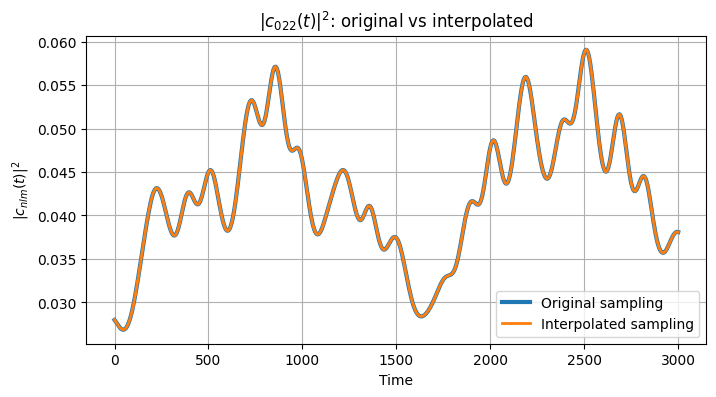

In [42]:
# Plot a particular mode (n=0, ℓ=0, m=0) and compare original vs interpolated
import importlib
import Eig_ULDM_packages.cnlm_spectral_analysis as _csa
importlib.reload(_csa)

n_plot, ell_plot, m_plot = 0, 2, 2
mass_physics = 12
mass = convert_between(mass_physics, 'M_solar_masses', '', 'm')
epsilon = 0
Normal = mass * (1 + epsilon**2)
key = (n_plot, ell_plot, m_plot)

if key not in c_file:
    raise KeyError(f'Coefficient for n={n_plot}, ℓ={ell_plot}, m={m_plot} not found in loaded data.')
if key not in c_dense_file:
    raise KeyError(f'Dense coefficient for n={n_plot}, ℓ={ell_plot}, m={m_plot} not found in dense data.')

fig = _csa.plot_cnlm_comparison(
    t_original=t_file,
    c_original=c_file[key],
    t_dense=t_dense_from_file,
    c_dense=c_dense_file[key],
    key=key,
    normalization=Normal,
)

## Step 10: Publication-Ready Single-Mode Plot (EPS Export)

Generate a clean, publication-quality figure of $|c_{nlm}(t)|^2$ for a single mode. The figure follows PRD (Physical Review D) styling conventions:
- No title, no grid, no legend
- Serif fonts with appropriate sizing
- Tick marks on all sides
- Exported as vector EPS format

The mode is inherited from Step 9 (`n_plot`, `ell_plot`, `m_plot`). Output is saved to the current working directory.

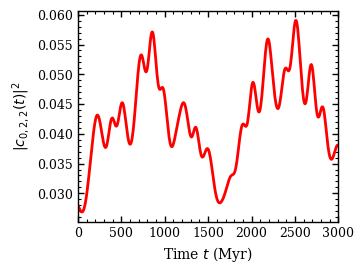

Saved EPS to: cnlm_n0_l2_mpos2_original.eps


In [43]:
# Paper-ready EPS plot: original sampling only (no title, no grid, no legend)
import importlib
import Eig_ULDM_packages.cnlm_spectral_analysis as _csa
importlib.reload(_csa)

# ---- Guards: ensure upstream cells were executed ----
required = ['t_file', 'c_file', 'Normal']
missing = [name for name in required if name not in globals()]
if missing:
    raise NameError(
        "Missing required variables/functions: " + ", ".join(missing) +
        ". Please run the earlier cells that compute/load c_{nlm}(t)."
    )

# ---- Select mode to plot (default matches cell 10) ----
n_plot_local = globals().get('n_plot', 1)
ell_plot_local = globals().get('ell_plot', 0)
m_plot_local = globals().get('m_plot', 0)
key_local = (n_plot_local, ell_plot_local, m_plot_local)

if key_local not in c_file:
    raise KeyError(
        f"Coefficient series {key_local} not found in c_file. "
        "Check (n, ℓ, m) indices or rerun computation."
    )

# ---- Export using module function ----
save_path = _csa.plot_cnlm_prd_single(
    t=t_file,
    c=c_file[key_local],
    key=key_local,
    normalization=Normal,
    xlim=(0.0, 3000.0),
)

## Step 11: Multi-Mode Overview Plot

Display $|c_{nlm}(t)|^2$ for multiple modes simultaneously on a single figure. This provides an overview of how different angular momentum states evolve over time.

**Visual encoding**:
- **Color** (rainbow gradient): Encodes $\ell$ value ($\ell_{\min}$ → red, $\ell_{\max}$ → violet)
- **Line style** (dash patterns): Encodes $|m|$ value
- **Line width**: Encodes sign of $m$ ($m=0$ thickest, $m>0$ medium, $m<0$ thinnest)

**User parameters**:
- `n_select`: Radial quantum number to display
- `l_min`, `l_max`: Range of $\ell$ values to include

Uses logarithmic y-axis to capture the dynamic range of mode amplitudes.

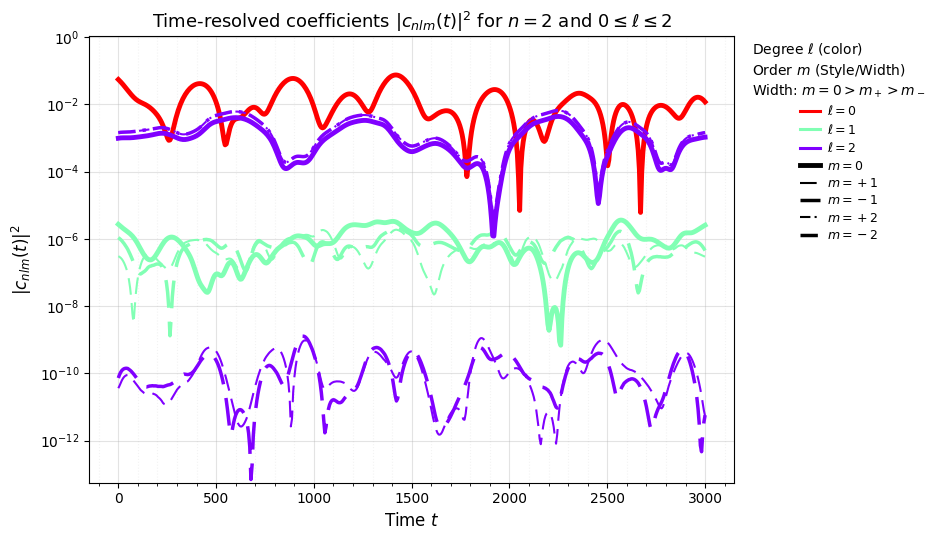

In [44]:
# Plot |c_{nlm}(t)| from c_file for a chosen n and ℓ in [l_min, l_max]
# - Colors by ℓ via rainbow gradient (ℓ=l_min warm/red, ℓ=l_max cold/violet)
# - Linestyles by |m|; line width encodes sign; m=0 thickest solid
import importlib
import Eig_ULDM_packages.cnlm_spectral_analysis as _csa
importlib.reload(_csa)

# ---- User inputs ----
n_select = 2      # radial index n to plot
l_min = 0         # minimum ℓ to include
l_max = 2         # maximum ℓ to include (plots all m in [-ℓ,ℓ] for each ℓ)

# Normalization consistent with cell 10
mass_physics = 12
mass_code_units = convert_between(mass_physics, 'M_solar_masses', '', 'm')
mass = mass_code_units
epsilon = 0.0
Normal = mass * (1.0 + epsilon**2)

# ---- Guards ----
if 'c_file' not in globals() or 't_file' not in globals():
    raise NameError("Required variables 'c_file' and 't_file' are not defined. Please run the earlier cells.")

# ---- Plot using module function ----
fig = _csa.plot_cnlm_multimode(
    t=t_file,
    c_dict=c_file,
    n_select=n_select,
    l_min=l_min,
    l_max=l_max,
    normalization=Normal,
    log_scale=True,
)

## Step 12: Spectral Analysis — 4-Panel EDA Diagnostic

Perform comprehensive exploratory data analysis (EDA) on a selected $c_{nlm}(t)$ mode using FFT-based spectral analysis.

**4-Panel Layout**:
1. **Time domain**: Real/imaginary parts and amplitude envelope
2. **Frequency spectrum**: FFT magnitude with detected peaks marked
3. **Argand diagram**: Complex plane trajectory (Re vs. Im)
4. **Phase dynamics**: Unwrapped phase with linear trend fit

**User options**:
- `analysis_mode`: `'complex'` (full signal), `'real'` (Re only), or `'imag'` (Im only)
- `use_dense`: Toggle between original and interpolated time series
- `apply_hann_window`: Apply Hann window before FFT to reduce spectral leakage
- `peak_rel_threshold`: Minimum relative amplitude for peak detection

The analysis result is stored in `result` for use in Step 13.

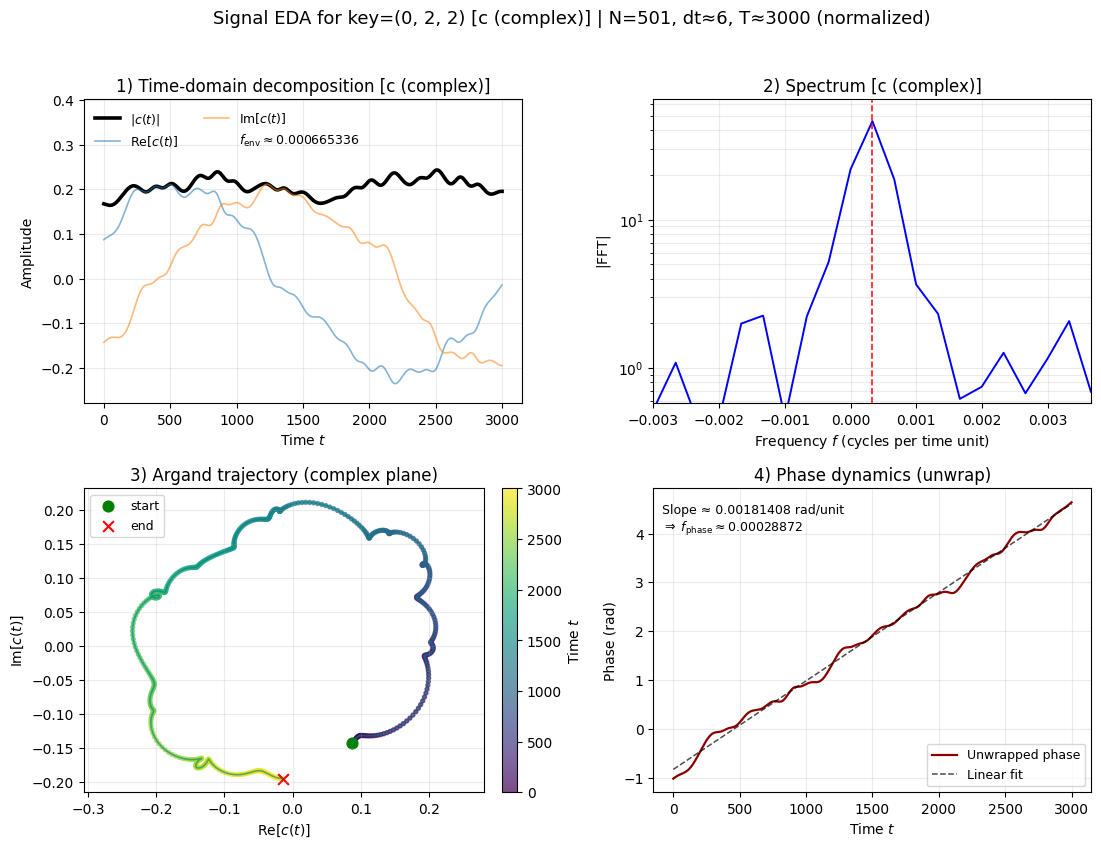


===== 4-panel quick readout (math-only) =====
Analysis mode: c (complex)
FFT: direct (non-uniformity ≈ 0.00e+00)

[1] Time-domain decomposition:
  - Black line |c(t)| is the envelope; blue/orange are Re/Im.

[2] Frequency domain:

  Spectral peaks (threshold = 5% of max):

    Positive frequency peaks (1 detected):
      1. f =  0.000332668,  |FFT| =  46.19,  rel_amp =  1.0000

    Negative frequency peaks (4 detected):
      1. f = -0.000332668,  |FFT| =  5.19902,  rel_amp =  0.1126
      2. f = -0.00133067,  |FFT| =  2.25517,  rel_amp =  0.0488
      3. f = -0.00266134,  |FFT| =  1.08604,  rel_amp =  0.0235
      4. f = -0.00432468,  |FFT| =  0.31502,  rel_amp =  0.0068

  Peak pattern detected: single
  Significant peaks (rel_amp >= 0.30):
    1. f =  0.000332668,  |FFT| =  46.19,  rel_amp =  1.0000

[3] Trajectory plot:
  - Near-circle: single frequency; spiral/petal: multi-frequency.

[4] Phase dynamics:
  - Phase-derived frequency f_phase ≈ 0.00028872

===== Spectral Analysis Su

In [40]:
# ================================
# Zero-assumption EDA for complex c_{nlm}(t)
# 4-panel diagnostic: time-domain, spectrum, Argand, phase dynamics
# ================================

import numpy as np
import matplotlib.pyplot as plt
import importlib
import Eig_ULDM_packages.cnlm_spectral_analysis as _csa
_csa = importlib.reload(_csa)  # pick up edits during development
from Eig_ULDM_packages.cnlm_spectral_analysis import (
    analyze_cnlm_spectrum,
    plot_4panel_eda,
    print_spectral_summary
)

# ---- User-specified mode (n, ℓ, m) to analyze ----
n_plot, ell_plot, m_plot = 0, 2, 2

# ---- Analysis target switch ----
# Options: 'complex' (full complex c), 'real' (Re[c]), 'imag' (Im[c])
analysis_mode = 'complex'  # 'complex', 'real', or 'imag'

# ---- Other optional switches ----
use_dense = False  # True: use interpolated dense time series
normalize_like_cell10 = True  # True: if Normal exists, normalize by sqrt(Normal)
apply_hann_window = True      # Use Hann window in FFT
detrend_mean = True           # Remove mean before FFT
peak_rel_threshold = 0.05     # Spectral peak threshold (relative to max)
top_k_peaks = 6               # Max number of peaks to print

# ---- Load time series ----
if use_dense and ('c_dense_from_file' in globals()) and ('t_dense_from_file' in globals()):
    t = np.asarray(t_dense_from_file)
    c_map = c_dense_from_file
    source_tag = 'dense(resampled)'
elif ('c_file' in globals()) and ('t_file' in globals()):
    t = np.asarray(t_file)
    c_map = c_file
    source_tag = 'original'
else:
    raise NameError("Could not find (t_file, c_file) or (t_dense_from_file, c_dense_from_file).")

key = (n_plot, ell_plot, m_plot)
if key not in c_map:
    raise KeyError(f"Key={key} not found. Available: {list(c_map.keys())[:5]}")

x_complex = np.asarray(c_map[key], dtype=np.complex128)

# ---- Normalization ----
normalization = None
if normalize_like_cell10 and ('Normal' in globals()):
    try:
        if float(Normal) > 0:
            normalization = float(Normal)
    except:
        pass

# ---- Perform spectral analysis ----
result = analyze_cnlm_spectrum(
    t_data=t,
    c_data=x_complex,
    key=key,
    analysis_mode=analysis_mode,
    normalization=normalization,
    apply_hann_window=apply_hann_window,
    detrend_mean=detrend_mean,
    peak_rel_threshold=peak_rel_threshold,
    top_k_peaks=top_k_peaks,
)

# ---- Generate 4-panel figure ----
fig = plot_4panel_eda(result)
plt.show()

# ---- Print summary ----
print_spectral_summary(result, top_k=top_k_peaks)

## Step 13: Export Publication-Ready Spectrum Figure

Export a 2-panel publication-ready figure (EPS format) containing:
1. **Left panel**: Time-domain signal $c_{nlm}(t)$
2. **Right panel**: FFT frequency spectrum with automatic zoom on detected peaks

This figure is suitable for inclusion in journal papers (PRD style). The output path is automatically generated based on the mode indices and analysis type.

**Prerequisite**: Step 12 must be run first to generate the `result` object.

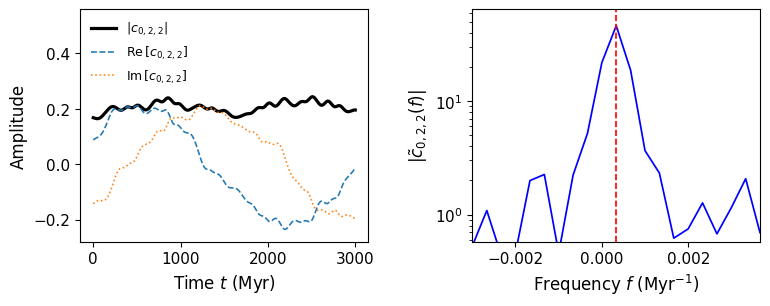

Saved EPS: /data/maudlin/alanz/Binary_soliton/128_6000_1000_doubleBoxsize_2/20260130_221325@128/Outputs/PRD_cnlm_time_spectrum_n0_ell2_m2.eps


PosixPath('/data/maudlin/alanz/Binary_soliton/128_6000_1000_doubleBoxsize_2/20260130_221325@128/Outputs/PRD_cnlm_time_spectrum_n0_ell2_m2.eps')

In [ ]:
# ================================
# PRD-ready: export subplots (1) + (2) as a 1×2 EPS/PDF figure
# ================================

from pathlib import Path
import importlib
import Eig_ULDM_packages.cnlm_spectral_analysis as _csa
_csa = importlib.reload(_csa)
from Eig_ULDM_packages.cnlm_spectral_analysis import export_prd_figure

# ---- Guard: make sure Cell 25 has been run (result object exists) ----
if 'result' not in globals():
    raise NameError("Please run Cell 25 (4-panel EDA) first. Variable 'result' not found.")

# ---- Save directory: current working directory (set by Step 3) ----
save_dir = Path.cwd()

# ---- Generate output base path ----
n, ell, m = result.key
mode_suffix = ''
if result.mode_label == 'Re[c]':
    mode_suffix = '_Re'
elif result.mode_label == 'Im[c]':
    mode_suffix = '_Im'
save_path = save_dir / f"PRD_cnlm_time_spectrum_n{n}_ell{ell}_m{m}{mode_suffix}.eps"

# ---- Left-panel time window (None => full time range) ----
export_time_xlim = (0.0, 3000.0)

# ---- Export (always EPS, plus PDF when save_pdf=True) ----
export_prd_figure(
    result,
    save_path=save_path,
    time_xlim=export_time_xlim,
    save_pdf=True,
 )